# 21장 딥러닝을 이용한 자연어 처리

[<img src="https://raw.githubusercontent.com/taehojo/taehojo.github.io/master/assets/images/linktocolab.png" align="left"/> ](https://colab.research.google.com/github/taehojo/deeplearning_4th/blob/master/colab/ch21-colab.ipynb)

## 1. 텍스트의 토큰화

In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Embedding
from tensorflow.keras.utils import to_categorical
from numpy import array

# 케라스의 텍스트 전처리와 관련한 함수중 text_to_word_sequence 함수를 불러옵니다.
from tensorflow.keras.preprocessing.text import text_to_word_sequence

# 전처리할 텍스트를 정합니다.
text = '해보지 않으면 해낼 수 없다. 과연 그럴까?'

# 해당 텍스트를 토큰화합니다.
result = text_to_word_sequence(text)
print("\n원문:\n", text)
print("\n토큰화:\n", result)


원문:
 해보지 않으면 해낼 수 없다. 과연 그럴까?

토큰화:
 ['해보지', '않으면', '해낼', '수', '없다', '과연', '그럴까']


In [ ]:
# 단어 빈도수 세기

# 전처리하려는 세 개의 문장을 정합니다.
docs = ['먼저 텍스트의 각 단어를 나누어 토큰화 합니다.',
       '텍스트의 단어로 토큰화해야 딥러닝에서 인식됩니다.',
       '토큰화한 결과는 딥러닝에서 사용할 수 있습니다.',
       ]

# 토큰화 함수를 이용해 전처리 하는 과정입니다.
token = Tokenizer()             # 토큰화 함수 지정
token.fit_on_texts(docs)       # 토큰화 함수에 문장 적용

# 단어의 빈도수를 계산한 결과를 각 옵션에 맞추어 출력합니다.
# Tokenizer()의 word_counts 함수는 순서를 기억하는 OrderedDict 클래스를 사용합니다.
print("\n단어 카운트:\n", token.word_counts)

# 출력되는 순서는 랜덤입니다.
print("\n문장 카운트: ", token.document_count)
print("\n각 단어가 몇 개의 문장에 포함되어 있는가:\n", token.word_docs)
print("\n각 단어에 매겨진 인덱스 값:\n",  token.word_index)


단어 카운트:
 OrderedDict([('먼저', 1), ('텍스트의', 2), ('각', 1), ('단어를', 1), ('나누어', 1), ('토큰화', 1), ('합니다', 1), ('단어로', 1), ('토큰화해야', 1), ('딥러닝에서', 2), ('인식됩니다', 1), ('토큰화한', 1), ('결과는', 1), ('사용할', 1), ('수', 1), ('있습니다', 1)])

문장 카운트:  3

각 단어가 몇 개의 문장에 포함되어 있는가:
 defaultdict(<class 'int'>, {'텍스트의': 2, '나누어': 1, '먼저': 1, '토큰화': 1, '합니다': 1, '각': 1, '단어를': 1, '단어로': 1, '딥러닝에서': 2, '인식됩니다': 1, '토큰화해야': 1, '사용할': 1, '수': 1, '결과는': 1, '토큰화한': 1, '있습니다': 1})

각 단어에 매겨진 인덱스 값:
 {'텍스트의': 1, '딥러닝에서': 2, '먼저': 3, '각': 4, '단어를': 5, '나누어': 6, '토큰화': 7, '합니다': 8, '단어로': 9, '토큰화해야': 10, '인식됩니다': 11, '토큰화한': 12, '결과는': 13, '사용할': 14, '수': 15, '있습니다': 16}


## 2. 단어의 원-핫 인코딩

In [ ]:
text="오랫동안 꿈꾸는 이는 그 꿈을 닮아간다"
token = Tokenizer()
token.fit_on_texts([text])
print(token.word_index)

{'오랫동안': 1, '꿈꾸는': 2, '이는': 3, '그': 4, '꿈을': 5, '닮아간다': 6}


In [ ]:
x=token.texts_to_sequences([text])
print(x)

[[1, 2, 3, 4, 5, 6]]


In [ ]:
#인덱스 수에 하나를 추가해서 원-핫 인코딩 배열 만들기
#원핫 인코딩 : 범주형 데이터를 0,1로 수치화
word_size = len(token.word_index) + 1
x = to_categorical(x, num_classes=word_size)
print(x)

[[[0. 1. 0. 0. 0. 0. 0.]
  [0. 0. 1. 0. 0. 0. 0.]
  [0. 0. 0. 1. 0. 0. 0.]
  [0. 0. 0. 0. 1. 0. 0.]
  [0. 0. 0. 0. 0. 1. 0.]
  [0. 0. 0. 0. 0. 0. 1.]]]


## 4.텍스트를 읽고 긍정, 부정 예측하기

In [ ]:
# 텍스트 리뷰 자료를 지정합니다.
docs = ["너무 재밌네요","최고예요","참 잘 만든 영화예요","추천하고 싶은 영화입니다","한번 더 보고싶네요","글쎄요","별로예요","생각보다 지루하네요","연기가 어색해요","재미없어요"]

# 긍정 리뷰는 1, 부정 리뷰는 0으로 클래스를 지정합니다.
classes = array([1,1,1,1,1,0,0,0,0,0])

# 토큰화
token = Tokenizer()
token.fit_on_texts(docs)
print(token.word_index)


{'너무': 1, '재밌네요': 2, '최고예요': 3, '참': 4, '잘': 5, '만든': 6, '영화예요': 7, '추천하고': 8, '싶은': 9, '영화입니다': 10, '한번': 11, '더': 12, '보고싶네요': 13, '글쎄요': 14, '별로예요': 15, '생각보다': 16, '지루하네요': 17, '연기가': 18, '어색해요': 19, '재미없어요': 20}


In [ ]:
x = token.texts_to_sequences(docs)
print("\n리뷰 텍스트, 토큰화 결과:\n",  x)


리뷰 텍스트, 토큰화 결과:
 [[1, 2], [3], [4, 5, 6, 7], [8, 9, 10], [11, 12, 13], [14], [15], [16, 17], [18, 19], [20]]


In [ ]:
# 패딩, 서로 다른 길이의 데이터를 4로 맞추어 줍니다.
padded_x = pad_sequences(x, 4)
print("\n패딩 결과:\n", padded_x)


패딩 결과:
 [[ 0  0  1  2]
 [ 0  0  0  3]
 [ 4  5  6  7]
 [ 0  8  9 10]
 [ 0 11 12 13]
 [ 0  0  0 14]
 [ 0  0  0 15]
 [ 0  0 16 17]
 [ 0  0 18 19]
 [ 0  0  0 20]]


In [ ]:
# 임베딩에 입력될 단어의 수를 지정합니다.
word_size = len(token.word_index) +1

# 단어 임베딩을 포함하여 딥러닝 모델을 만들고 결과를 출력합니다.
model = Sequential()
model.add(Embedding(word_size, 8))
model.build((None, 4))
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 4, 8)           │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201 (804.00 B)

 Trainable params: 201 (804.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(padded_x, classes, epochs=20)
print("\n Accuracy: %.4f" % (model.evaluate(padded_x, classes)[1]))

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step - accuracy: 0.6000 - loss: 0.6906
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7000 - loss: 0.6883
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8000 - loss: 0.6860
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8000 - loss: 0.6838
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8000 - loss: 0.6815
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8000 - loss: 0.6792
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9000 - loss: 0.6770
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9000 - loss: 0.6747
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 1.0000 - loss: 0.6724
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 1.0000 - loss: 0.6701
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.6679
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 1.0000 - loss: 0.6656


In [14]:
!pip install KoNLPy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 34.2 MB/s eta 0:00:00


In [41]:
import konlpy


In [22]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

string1="my favorite subject is math"
string2="my favorite subject is math,english, economic adn computer science."
nltk.word_tokenize(string1)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['my', 'favorite', 'subject', 'is', 'math']

In [23]:
nltk.word_tokenize(string2)

['my',
 'favorite',
 'subject',
 'is',
 'math',
 ',',
 'english',
 ',',
 'economic',
 'adn',
 'computer',
 'science',
 '.']

In [25]:
import konlpy
# konlpy.download('punkt')
# konlpy.download('punkt_tab') konlpy 이거 없으므로 아래 다른 코드로 바꾼다

string1="안녕하세요. 딥러닝은 쉽나요? 어렵나요?"
konlpy.word_tokenize(string1)


ValueError: Could not find a matching item to download

In [27]:
from konlpy.tag import Okt

# 객체 생성 (이때 필요한 데이터가 자동으로 로드됩니다)
okt = Okt()

# 형태소 분석 실행
text = "공부하기 정말 좋은 날씨네요!"
print(okt.morphs(text))

['공부', '하기', '정말', '좋은', '날씨', '네', '요', '!']


In [29]:
#komoran: 품사 태깅 정확도가 높고 속도가 빠름, 문장 구조 분석에 비교적 강함
from konlpy.tag import Komoran
komoran=Komoran()
print(komoran.morphs(text))

from konlpy.tag import Kkma
kkma=Kkma()
print(kkma.morphs(text))
print(kkma.pos(text))

#morphs :small gradually, an actual linguistic form, 형태소 추출
#pos : 품사 태깅
# nouns: 명사만 추출


['공부', '하', '기', '정말', '좋은 날', '씨', '네요', '!']
['공부', '하', '기', '정말', '좋', '은', '날씨', '이', '네요', '!']
[('공부', 'NNG'), ('하', 'XSV'), ('기', 'ETN'), ('정말', 'MAG'), ('좋', 'VA'), ('은', 'ETD'), ('날씨', 'NNG'), ('이', 'VCP'), ('네요', 'EFN'), ('!', 'SF')]


## 1.기본 단어 빈도 분석
- 한글 텍스틑 처리 시, 형태소 분석기(Konlpy)통해 명사 단위 추출 가능2

In [30]:
from konlpy.tag import Okt
from collections import Counter

# 1. 샘플 데이터
text = "자연어 처리는 정말 재밌습니다. 파이썬을 이용한 자연어 처리 공부는 즐겁습니다. 공부는 계속되어야 합니다."

# 2. 형태소 분석 및 명사 추출
okt = Okt()
nouns = okt.nouns(text)

# 3. 빈도수 계산
count = Counter(nouns)

# 4. 가장 많이 등장한 상위 3개 단어 출력
print(count.most_common(3))

[('자연어', 2), ('처리', 2), ('공부', 2)]


## 2.시각화 : 워드 클라우드
- 표로 보는 것보다 한눈에 들어오게 만들고 싶을때

In [37]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,482 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


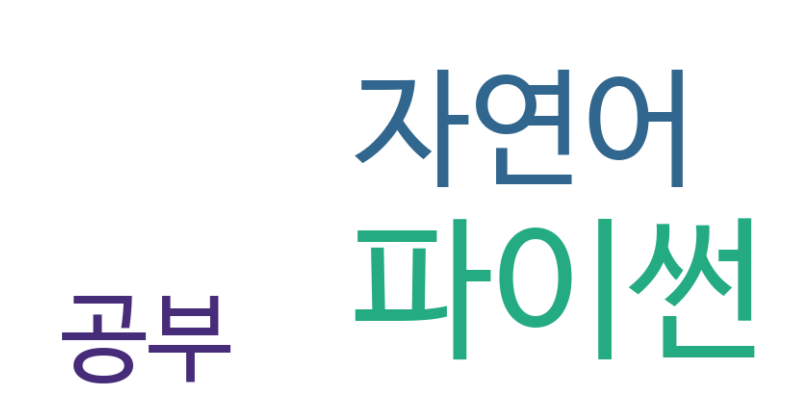

In [38]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. 단어 빈도 데이터 준비 (count 변수가 이전에 정의되어 있어야 함)
word_counts = dict(count)

# 2. 워드클라우드 객체 생성 (코랩 리눅스 환경의 폰트 경로 입력)
wc = WordCloud(
    font_path='/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf',
    background_color='white',
    width=800,
    height=400
)

# 데이터 생성
cloud = wc.generate_from_frequencies(word_counts)

# 3. 화면에 출력
plt.figure(figsize=(10, 5))
plt.imshow(cloud, interpolation='bilinear') # 이미지를 부드럽게 출력
plt.axis('off')
plt.show()

## 3.분석 시 주의할 점
- stopwords 제거: 은는이가 것때 등등

## 4.머신러닝을 위한 수치화 ㅣ countervectorier

In [39]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = ['자연어 처리 공부 재밌다', '파이썬 자연어 처리 어렵다']
vector = CountVectorizer()

# 단어 빈도를 담은 행렬 생성
print(vector.fit_transform(corpus).toarray())
# 각 인덱스에 해당하는 단어 확인
print(vector.vocabulary_)

[[1 0 1 1 1 0]
 [0 1 1 0 1 1]]
{'자연어': 2, '처리': 4, '공부': 0, '재밌다': 3, '파이썬': 5, '어렵다': 1}
